# Spike-Timing Perturbation Visualisation

This notebook illustrates the **spike-timing perturbation** used in the
hidden-layer perturbation experiments (`ccisi/ccisi_delay.ipynb` and
`realistic/shd/shd_train.py`, which share the same logic). The perturbation
relocates a fraction *f* of **each neuron's** spikes to random, previously
silent time bins. It **preserves every neuron's total spike count** (the rate
code) while destroying the fine spike timing.

Here we apply it, with **f = 0.5**, to one randomly picked sample that is shared
by the two synthetic datasets:

- **ISI** — 10 independent neurons (`isi/isi_dataset.h5`).
- **CCISI** — 20 neurons arranged as 10 correlated pairs (`ccisi/ccisi_dataset.h5`).

Both datasets index their samples element-wise, so a single index selects the
same (firing rate, ISI) feature in both.

**Layout.** A 2x2 grid of four subplots: the **top row** shows the original ISI
and CCISI spike trains, and the **bottom row** shows the corresponding perturbed
spike trains (left column = ISI, right column = CCISI).

## 1. Setup

Imports, dataset paths, the perturbation strength `f`, and shared styling
constants (reused from `data_visualization.ipynb`).

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Datasets and perturbation strength.
ISI_DATASET_PATH = os.path.join("isi", "isi_dataset.h5")
CCISI_DATASET_PATH = os.path.join("ccisi", "ccisi_dataset.h5")
PERTURB_F = 0.5   # Fraction of each neuron's spikes to relocate.
SEED = 42         # Controls both the random sample pick and the perturbation.

# Class styling shared with data_visualization.ipynb (classic blue / red).
CLASS_COLORS = {0: "blue", 1: "red"}

# Colours cycling through CCISI neuron pairs in the raster plots.
PAIR_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
    "#66c2a5", "#fc8d62",
]

## 2. Perturbation logic

`partial_randomize_spike_train` is the exact function from
`ccisi/ccisi_delay.ipynb`. For each neuron it removes a fraction *f* of the
spikes and re-places the same number at uniformly random empty time bins, so the
per-neuron spike count is preserved and only timing is disrupted.

`realistic/shd/shd_train.py` implements the same idea with a per-spike coin flip
(each spike is relocated independently with probability *f*); that is
statistically equivalent in expectation and also preserves the spike count.

In [2]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    For every neuron a fraction *f* of its spikes is removed and re-placed at
    uniformly random, previously-silent time bins. The total spike count per
    neuron is preserved, so the rate code is unchanged and only the spike
    timing is disrupted.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Retry budget per displaced spike when searching for an
            empty time bin.

    Returns:
        A new perturbed spike train with the same shape. The input array is
        left unmodified.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        # Choose which spikes to relocate, then clear them.
        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        # Re-place each removed spike at a random empty time bin.
        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train

## 3. Load the datasets

Load ISI and CCISI. They share the `firing_rates` and `isis` feature arrays
element-wise, so one sample index describes the same feature point in both.

In [3]:
def load_dataset(
    path: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Load an HDF5 spike-train dataset.

    Args:
        path: Path to the HDF5 file.

    Returns:
        Tuple of (spike_trains, labels, firing_rates, isis).
    """
    with h5py.File(path, "r") as hdf:
        spike_trains = hdf["X"][:]
        labels = hdf["Y"][:].ravel()
        firing_rates = hdf["firing_rates"][:]
        isis = hdf["isis"][:]
    return spike_trains, labels, firing_rates, isis


isi_trains, isi_labels, firing_rates, isis = load_dataset(ISI_DATASET_PATH)
ccisi_trains, ccisi_labels, _, _ = load_dataset(CCISI_DATASET_PATH)

print(f"ISI:   {isi_trains.shape}  (samples, neurons, time)")
print(f"CCISI: {ccisi_trains.shape}  (samples, neurons, time)")

ISI:   (3598, 10, 1000)  (samples, neurons, time)
CCISI: (3598, 20, 1000)  (samples, neurons, time)


## 4. Pick a random sample and perturb it

Seed the RNG (so the pick and the perturbation are reproducible), draw one
random sample index, and apply `partial_randomize_spike_train` with `f = 0.5`
to that sample in both datasets. The printout confirms the per-neuron spike
count is preserved.

In [4]:
np.random.seed(SEED)
sample_idx = int(np.random.randint(isi_trains.shape[0]))

isi_original = isi_trains[sample_idx]
ccisi_original = ccisi_trains[sample_idx]

# Identical perturbation logic applied to each dataset's chosen sample.
isi_perturbed = partial_randomize_spike_train(isi_original, f=PERTURB_F)
ccisi_perturbed = partial_randomize_spike_train(ccisi_original, f=PERTURB_F)

sample_class = int(isi_labels[sample_idx])
print(
    f"Sample #{sample_idx}: class {sample_class}, "
    f"FR = {firing_rates[sample_idx]:.1f} Hz, ISI = {isis[sample_idx]:.0f} ms"
)
print(
    f"ISI   total spikes  original {int(isi_original.sum())}  ->  "
    f"perturbed {int(isi_perturbed.sum())}"
)
print(
    f"CCISI total spikes  original {int(ccisi_original.sum())}  ->  "
    f"perturbed {int(ccisi_perturbed.sum())}"
)

Sample #3174: class 1, FR = 4.0 Hz, ISI = 21 ms
ISI   total spikes  original 80  ->  perturbed 80
CCISI total spikes  original 80  ->  perturbed 80


## 5. Raster-plot helpers

Two helpers draw a spike train onto a supplied Axes: ISI in a single class
colour, and CCISI with each neuron pair sharing a colour (matching
`data_visualization.ipynb`).

In [5]:
def draw_isi_raster(
    ax: plt.Axes,
    train: np.ndarray,
    color: str,
    title: str,
) -> None:
    """Draw an ISI spike train (all neurons in one colour) onto *ax*."""
    num_neurons = train.shape[0]
    for neuron_idx in range(num_neurons):
        spike_times = np.where(train[neuron_idx] == 1)[0]
        ax.vlines(
            spike_times, neuron_idx + 0.5, neuron_idx + 1.5,
            color=color, linewidth=0.8,
        )
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Neuron")
    ax.set_yticks(range(1, num_neurons + 1))
    ax.set_ylim(0.5, num_neurons + 0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)


def draw_ccisi_raster(
    ax: plt.Axes,
    train: np.ndarray,
    title: str,
) -> None:
    """Draw a CCISI spike train (neuron pairs in matching colours) onto *ax*."""
    num_neurons = train.shape[0]
    for pair_idx in range(num_neurons // 2):
        color = PAIR_COLORS[pair_idx % len(PAIR_COLORS)]
        for neuron_idx in (pair_idx * 2, pair_idx * 2 + 1):
            spike_times = np.where(train[neuron_idx] == 1)[0]
            ax.vlines(
                spike_times, neuron_idx + 0.5, neuron_idx + 1.5,
                color=color, linewidth=0.8,
            )
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Neuron")
    ax.set_yticks(range(1, num_neurons + 1))
    ax.set_yticklabels(
        [f"{'a' if i % 2 == 0 else 'b'}{i // 2}" for i in range(num_neurons)],
        fontsize=6,
    )
    ax.set_ylim(0.5, num_neurons + 0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)

## 6. The 2x2 comparison figure

Top row: the original ISI and CCISI spike trains. Bottom row: the corresponding
`f = 0.5` perturbed spike trains. All panels share the time axis, so the loss of
timing structure between each original and its perturbed counterpart is directly
comparable.

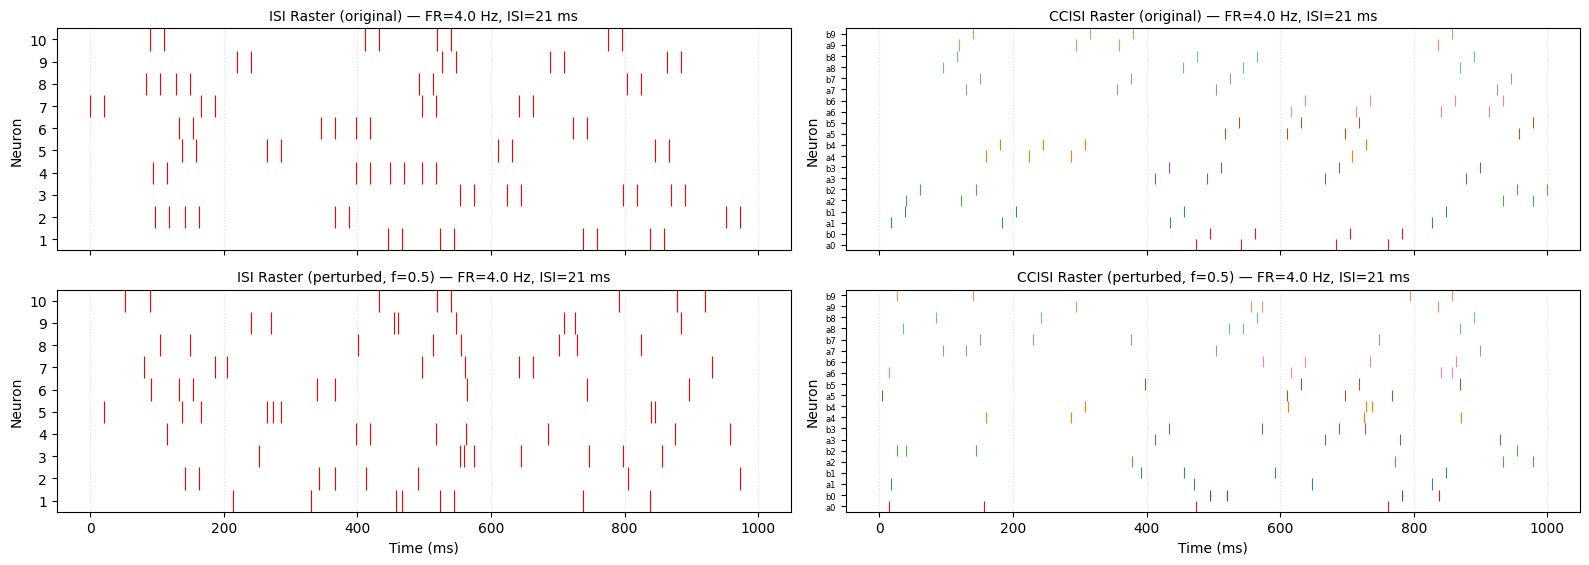

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6), sharex=True)

class_color = CLASS_COLORS[sample_class]
label = (
    f"FR={firing_rates[sample_idx]:.1f} Hz, "
    f"ISI={isis[sample_idx]:.0f} ms"
)

# Top row: original spike trains.
draw_isi_raster(
    axes[0, 0], isi_original, class_color, f"ISI Raster (original) — {label}"
)
draw_ccisi_raster(
    axes[0, 1], ccisi_original, f"CCISI Raster (original) — {label}"
)

# Bottom row: corresponding perturbed spike trains (f = 0.5).
draw_isi_raster(
    axes[1, 0], isi_perturbed, class_color,
    f"ISI Raster (perturbed, f={PERTURB_F}) — {label}",
)
draw_ccisi_raster(
    axes[1, 1], ccisi_perturbed,
    f"CCISI Raster (perturbed, f={PERTURB_F}) — {label}",
)

for ax in axes[1, :]:
    ax.set_xlabel("Time (ms)")

'''fig.suptitle(
    f"Spike-timing perturbation (f = {PERTURB_F}) on a random ISI/CCISI "
    f"sample (#{sample_idx})\n"
    "Per-neuron spike counts are preserved; only spike timing is randomised.",
    fontsize=13,
)'''
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()